# Data Analysis Project
## Prepared by Brian Kimtai

# 🏠 House Price Prediction Using Machine Learning

## Problem Statement
The goal of this project is to predict house prices based on demographic and geographic features.

## Objectives

- To understand the dataset  
- To explore relationships between variables  
- To build predictive models  
- To evaluate model performance  

In [1]:
# Importing Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
#Loading Dataset 
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Data Overview
We inspect the dataset structure, missing values, and summary statistics.

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


The dataset contains numerical features with no missing values.

## DATA VISUALIZATION
## Distribution of House Prices

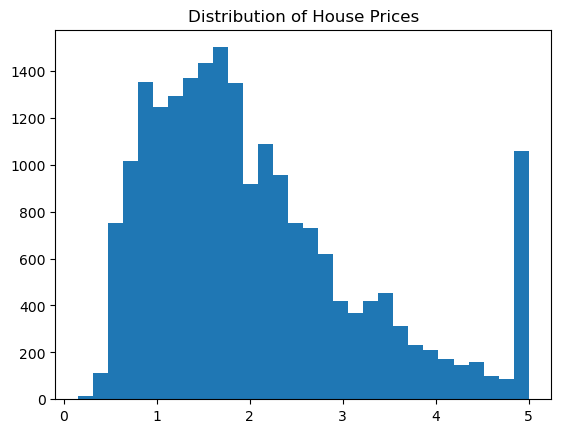

In [4]:
plt.hist(df['MedHouseVal'], bins=30)
plt.title("Distribution of House Prices")
plt.show()

The distribution appears slightly skewed, indicating variation in house prices.

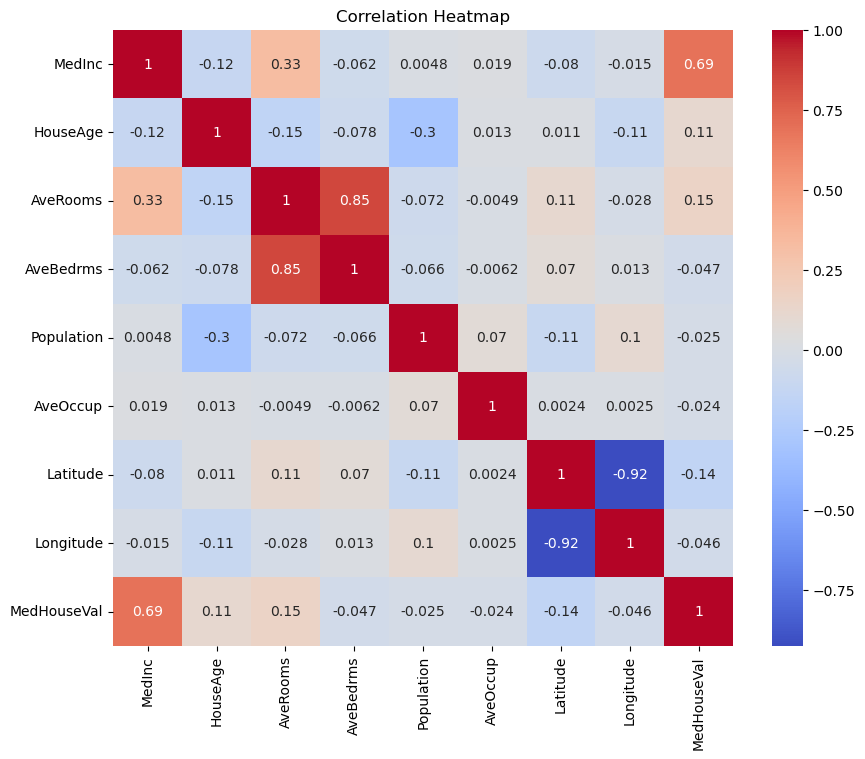

In [5]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Median income shows strong positive correlation with house prices.

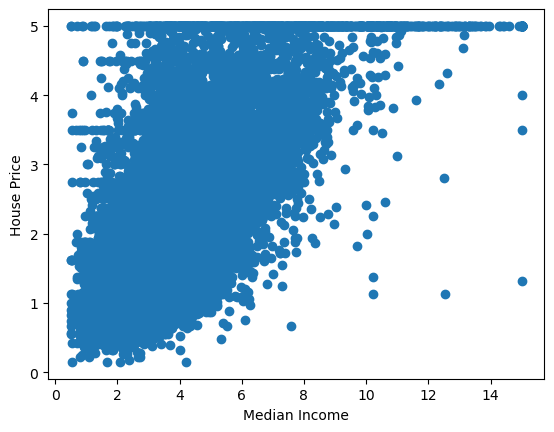

In [6]:
# scatter plot
plt.scatter(df['MedInc'], df['MedHouseVal'])
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.show()

Higher income areas tend to have higher house prices.

## Data Preparation
We split the dataset into training and testing sets.

In [7]:

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## MODEL BUILDING
## Linear Regression

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## Random Forest

In [9]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

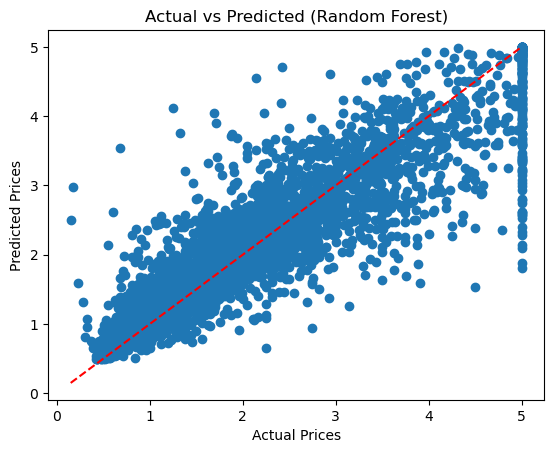

In [10]:
plt.scatter(y_test, y_pred_rf)

# Add perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

## Model Performance Visualization

The scatter plot compares actual and predicted values.

Points closer to the diagonal line indicate better predictions, 
showing that the Random Forest model performs well.

## MODEL EVALUATION

In [11]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Linear Regression:", mae_lr, r2_lr)
print("Random Forest:", mae_rf, r2_rf)

Linear Regression: 0.5332001304956558 0.575787706032451
Random Forest: 0.3273061556686048 0.8046959815648892


In [12]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "R2": [r2_lr, r2_rf]
})

results

,Model,MAE,R2
0,Linear Regression,0.533200,0.575788
1,Random Forest,0.327306,0.804696


## Model Comparison Table

The table summarizes the performance of both models. 
Random Forest clearly outperforms Linear Regression in both MAE and R².

## Model Evaluation and Comparison

Two models were evaluated: Linear Regression and Random Forest.

- Linear Regression achieved an MAE of 0.533 and an R² score of 0.576.
- Random Forest achieved a lower MAE of 0.326 and a higher R² score of 0.807.

The Random Forest model performs significantly better than Linear Regression. 
This is because Random Forest can capture complex, non-linear relationships in the data, 
while Linear Regression assumes a linear relationship.

Therefore, Random Forest is selected as the best model for this problem.

### Model Insight

The Random Forest model may be prone to overfitting due to its complexity, 
though its strong performance on test data suggests good generalization.

## FEATURE IMPORTANCE

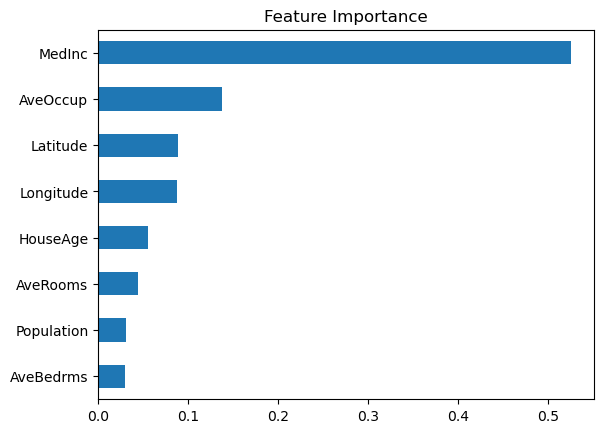

In [13]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

## Feature Importance Interpretation

The feature importance plot shows that median income (MedInc) 
is the most influential variable in predicting house prices.

This indicates that economic factors play a major role in determining housing value.

## Limitations

- The dataset is limited to California housing data
- No advanced feature engineering was applied
- Hyperparameter tuning was minimal

## Conclusion

This project demonstrated the application of machine learning in predicting housing prices.

Random Forest significantly outperformed Linear Regression, achieving lower prediction error and higher explanatory power.

The results suggest that housing prices are influenced by complex, non-linear relationships, with median income being the most important factor.

Future improvements could include advanced models like XGBoost and hyperparameter tuning.